# Text Classification with 1-D CNN on IMDB Dataset

This notebook implements a 1-D Convolutional Neural Network for sentiment classification (positive/negative) on the IMDB movie reviews dataset.

**Key concepts covered:**
- Text preprocessing & vocabulary building
- Trainable word embeddings
- 1-D CNN with multiple filter sizes (n-gram features)
- Global max-pooling over time
- Binary sentiment classification

In [1]:
import re
import time
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1) Load IMDB Dataset

We use the `datasets` library (HuggingFace) to load IMDB. Install if needed:
```bash
pip install datasets
```

In [2]:
from datasets import load_dataset

raw = load_dataset("imdb")
print(raw)
print("\nSample review:")
print(raw["train"][0]["text"][:300])
print("\nLabel:", raw["train"][0]["label"])  # 0=neg, 1=pos

/opt/miniconda3/envs/AI/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 355232.74 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

Label: 0


## 2) Text Preprocessing & Vocabulary

In [3]:
def tokenize(text: str):
    """Simple whitespace + punctuation tokenizer."""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)          # strip HTML tags
    text = re.sub(r"[^a-z0-9']", " ", text)        # keep letters/digits/apostrophe
    return text.split()

# Build vocabulary from training set
MAX_VOCAB  = 20_000   # keep top-N words
MIN_FREQ   = 2        # discard rare words
MAX_LEN    = 512      # truncate reviews to this many tokens

print("Building vocabulary...")
counter = Counter()
for ex in raw["train"]:
    counter.update(tokenize(ex["text"]))

SPECIAL = ["<pad>", "<unk>"]
vocab   = SPECIAL + [w for w, c in counter.most_common(MAX_VOCAB) if c >= MIN_FREQ]
stoi    = {w: i for i, w in enumerate(vocab)}
itos    = {i: w for w, i in stoi.items()}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

print(f"Vocabulary size: {len(vocab):,}")
print("Most common:", counter.most_common(10))

Building vocabulary...
Vocabulary size: 20,002
Most common: [('the', 336194), ('and', 164129), ('a', 163091), ('of', 145849), ('to', 135710), ('is', 107318), ('in', 93945), ('it', 79128), ('i', 77188), ('this', 75977)]


## 3) Dataset & DataLoader

In [4]:
def encode(text: str, max_len: int = MAX_LEN):
    tokens = tokenize(text)[:max_len]
    return [stoi.get(t, UNK_IDX) for t in tokens]


class IMDBDataset(Dataset):
    def __init__(self, split):
        self.data = [
            (encode(ex["text"]), ex["label"])
            for ex in raw[split]
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids, label = self.data[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)


def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return texts_padded, torch.stack(labels)


BATCH_SIZE = 64

train_ds = IMDBDataset("train")
test_ds  = IMDBDataset("test")

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_dl)} | Test batches: {len(test_dl)}")
x_sample, y_sample = next(iter(train_dl))
print("Batch shape:", x_sample.shape, "| Labels:", y_sample[:8])

Train batches: 391 | Test batches: 391
Batch shape: torch.Size([64, 512]) | Labels: tensor([1, 0, 1, 1, 1, 0, 1, 0])


## 4) 1-D CNN Model

Architecture:
```
Embedding  →  [Conv1d(k=2), Conv1d(k=3), Conv1d(k=4)]  →  GlobalMaxPool  →  Concat  →  Dropout  →  FC
```

Using **multiple filter sizes** mimics n-gram detectors. Each Conv1d operates across the sequence dimension, extracting local features of different window sizes.

In [5]:
class TextCNN(nn.Module):
    """
    1-D CNN for text classification.

    Parameters
    ----------
    vocab_size   : vocabulary size
    embed_dim    : embedding dimension
    num_filters  : number of filters per kernel size
    kernel_sizes : list of kernel (window) sizes
    num_classes  : output classes (2 for binary)
    dropout      : dropout probability before the final FC layer
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 128,
        num_filters: int = 100,
        kernel_sizes: list = [2, 3, 4],
        num_classes: int = 2,
        dropout: float = 0.5,
        pad_idx: int = 0,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # One Conv1d per kernel size
        # Input channels = embed_dim, Output channels = num_filters
        # Conv1d expects (B, C_in, L) -> we treat embed_dim as channels
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim,
                      out_channels=num_filters,
                      kernel_size=k)
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        # x: (B, L)
        embedded = self.embedding(x)        # (B, L, E)
        embedded = embedded.permute(0, 2, 1)  # (B, E, L)  — Conv1d wants (B, C, L)

        # Apply each conv + ReLU + global max-pool
        pooled = []
        for conv in self.convs:
            c = F.relu(conv(embedded))       # (B, num_filters, L - k + 1)
            p = c.max(dim=2).values          # (B, num_filters)  — global max pool
            pooled.append(p)

        cat = torch.cat(pooled, dim=1)       # (B, num_filters * len(kernel_sizes))
        out = self.dropout(cat)
        return self.fc(out)                  # (B, num_classes)


model = TextCNN(
    vocab_size=len(vocab),
    embed_dim=128,
    num_filters=100,
    kernel_sizes=[2, 3, 4],
    num_classes=2,
    dropout=0.5,
    pad_idx=PAD_IDX,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

TextCNN(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 100, kernel_size=(2,), stride=(1,))
    (1): Conv1d(128, 100, kernel_size=(3,), stride=(1,))
    (2): Conv1d(128, 100, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=2, bias=True)
)

Trainable parameters: 2,676,358


## 5) Training & Evaluation Utilities

In [6]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss   = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = loss_fn(logits, y)

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / total, correct / total


def train(
    model, train_loader, test_loader,
    epochs=10, lr=1e-3, weight_decay=1e-4
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn   = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        te_loss, te_acc = evaluate(model, test_loader, loss_fn)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(
            f"Epoch {epoch:02d}/{epochs}  "
            f"train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  "
            f"test  loss={te_loss:.4f}  acc={te_acc:.4f}  "
            f"[{time.time()-t0:.1f}s]"
        )

    return history

## 6) Train the Model

In [7]:
history = train(
    model, train_dl, test_dl,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

print(f"\nBest test accuracy: {max(history['test_acc']):.4f}")

Epoch 01/10  train loss=0.6084  acc=0.6743  |  test  loss=0.4524  acc=0.7932  [6.8s]
Epoch 02/10  train loss=0.4611  acc=0.7812  |  test  loss=0.3725  acc=0.8411  [6.5s]
Epoch 03/10  train loss=0.4003  acc=0.8165  |  test  loss=0.3383  acc=0.8569  [6.5s]
Epoch 04/10  train loss=0.3528  acc=0.8475  |  test  loss=0.3320  acc=0.8530  [6.4s]
Epoch 05/10  train loss=0.3256  acc=0.8596  |  test  loss=0.3081  acc=0.8686  [6.6s]
Epoch 06/10  train loss=0.3025  acc=0.8696  |  test  loss=0.2979  acc=0.8741  [6.6s]
Epoch 07/10  train loss=0.2790  acc=0.8816  |  test  loss=0.2911  acc=0.8780  [6.5s]
Epoch 08/10  train loss=0.2650  acc=0.8936  |  test  loss=0.2876  acc=0.8784  [6.7s]
Epoch 09/10  train loss=0.2541  acc=0.8963  |  test  loss=0.2809  acc=0.8820  [6.7s]
Epoch 10/10  train loss=0.2389  acc=0.9031  |  test  loss=0.2783  acc=0.8828  [6.5s]

Best test accuracy: 0.8828


## 7) Plot Training Curves

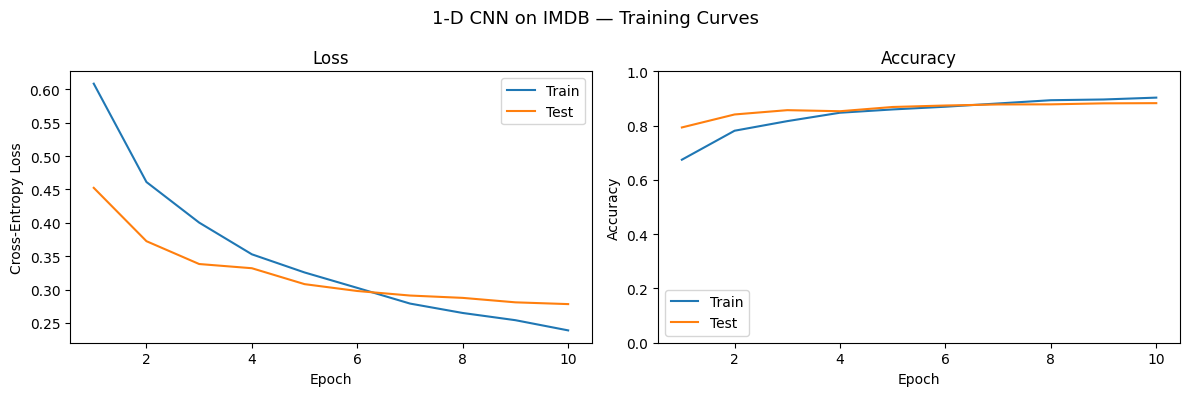

In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["test_loss"],  label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["test_acc"],  label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()

fig.suptitle("1-D CNN on IMDB — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 8) Ablation: Effect of Kernel Sizes & Filter Count

Compare different kernel size combinations and filter counts to understand their impact on accuracy.

In [10]:
configs = [
    {"kernel_sizes": [3],       "num_filters": 100, "label": "k=[3], f=100"},
    {"kernel_sizes": [2, 3, 4], "num_filters": 100, "label": "k=[2,3,4], f=100"},
    {"kernel_sizes": [2, 3, 4], "num_filters": 200, "label": "k=[2,3,4], f=200"},
    {"kernel_sizes": [3, 4, 5], "num_filters": 100, "label": "k=[3,4,5], f=100"},
]

ABLATION_EPOCHS = 5
results = []

for cfg in configs:
    print(f"\n--- {cfg['label']} ---")
    m = TextCNN(
        vocab_size=len(vocab),
        embed_dim=128,
        num_filters=cfg["num_filters"],
        kernel_sizes=cfg["kernel_sizes"],
        num_classes=2,
        dropout=0.5,
        pad_idx=PAD_IDX,
    ).to(device)
    h = train(m, train_dl, test_dl, epochs=ABLATION_EPOCHS, lr=1e-3)
    best_acc = max(h["test_acc"])
    results.append({"label": cfg["label"], "best_test_acc": best_acc, "history": h})
    print(f"Best test acc: {best_acc:.4f}")


--- k=[3], f=100 ---
Epoch 01/5  train loss=0.6516  acc=0.6270  |  test  loss=0.5118  acc=0.7650  [3.6s]
Epoch 02/5  train loss=0.5147  acc=0.7448  |  test  loss=0.4248  acc=0.8156  [3.5s]
Epoch 03/5  train loss=0.4519  acc=0.7866  |  test  loss=0.3828  acc=0.8366  [3.6s]
Epoch 04/5  train loss=0.4048  acc=0.8172  |  test  loss=0.3608  acc=0.8453  [3.4s]
Epoch 05/5  train loss=0.3755  acc=0.8359  |  test  loss=0.3444  acc=0.8521  [3.4s]
Best test acc: 0.8521

--- k=[2,3,4], f=100 ---
Epoch 01/5  train loss=0.6231  acc=0.6647  |  test  loss=0.4396  acc=0.8139  [6.6s]
Epoch 02/5  train loss=0.4664  acc=0.7782  |  test  loss=0.3744  acc=0.8406  [6.8s]
Epoch 03/5  train loss=0.4105  acc=0.8118  |  test  loss=0.3454  acc=0.8502  [6.8s]
Epoch 04/5  train loss=0.3530  acc=0.8435  |  test  loss=0.3280  acc=0.8594  [6.8s]
Epoch 05/5  train loss=0.3305  acc=0.8554  |  test  loss=0.3150  acc=0.8654  [6.9s]
Best test acc: 0.8654

--- k=[2,3,4], f=200 ---
Epoch 01/5  train loss=0.5975  acc=0.6911 

Config                      Best Test Acc
------------------------------------------
k=[3], f=100                       0.8521
k=[2,3,4], f=100                   0.8654
k=[2,3,4], f=200                   0.8728
k=[3,4,5], f=100                   0.8638


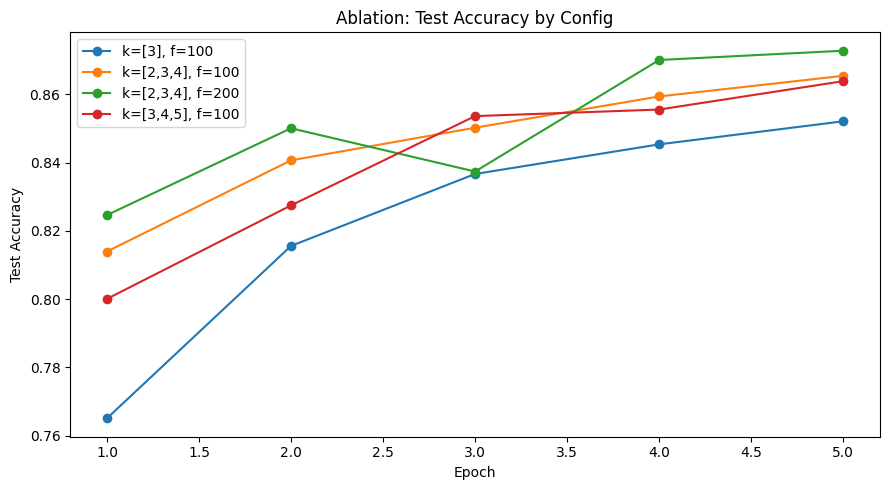

In [11]:
# Summary table
print(f"{'Config':<25} {'Best Test Acc':>15}")
print("-" * 42)
for r in results:
    print(f"{r['label']:<25} {r['best_test_acc']:>15.4f}")

# Plot accuracy curves for all configs
plt.figure(figsize=(9, 5))
for r in results:
    plt.plot(range(1, ABLATION_EPOCHS + 1), r["history"]["test_acc"], marker="o", label=r["label"])
plt.title("Ablation: Test Accuracy by Config")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 9) Inference on Custom Reviews

In [12]:
@torch.no_grad()
def predict(text: str, model=model):
    model.eval()
    ids = encode(text)
    if not ids:
        return "unknown", 0.0
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, L)
    logits = model(x)
    probs  = F.softmax(logits, dim=1)[0]
    label  = int(logits.argmax(1).item())
    return ("positive" if label == 1 else "negative"), float(probs[label])


test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat.",
    "Terrible film. Boring, predictable, and a complete waste of time. I walked out after 30 minutes.",
    "It was okay, nothing special. Some scenes were good but overall it felt a bit flat.",
    "One of the best movies I've seen in years. A masterpiece of storytelling and cinematography.",
]

print(f"{'Review':<70} {'Sentiment':<12} {'Confidence'}")
print("-" * 95)
for review in test_reviews:
    sentiment, confidence = predict(review)
    print(f"{review[:68]:<70} {sentiment:<12} {confidence:.4f}")

Review                                                                 Sentiment    Confidence
-----------------------------------------------------------------------------------------------
This movie was absolutely fantastic! The acting was superb and the p   positive     0.7030
Terrible film. Boring, predictable, and a complete waste of time. I    negative     0.9991
It was okay, nothing special. Some scenes were good but overall it f   negative     0.8561
One of the best movies I've seen in years. A masterpiece of storytel   positive     0.9865


## Summary

| Component | Detail |
|---|---|
| Dataset | IMDB (25k train / 25k test) |
| Vocabulary | Top 20,000 words, min freq=2 |
| Embedding | 128-dim trainable |
| Conv filters | 100 per kernel size |
| Kernel sizes | [2, 3, 4] — bigram, trigram, 4-gram detectors |
| Pooling | Global max-pool over time |
| Dropout | 0.5 before FC layer |
| Optimizer | Adam (lr=1e-3, StepLR decay) |
| Typical test acc | ~88–90% |

**Why 1-D CNN works for text:**  
Each Conv1d filter slides over consecutive word embeddings and acts as an **n-gram detector**. Global max-pooling keeps the strongest activation regardless of position, making the model invariant to where the key phrase appears in the review.